In [8]:

! pip install torch torchvision pillow matplotlib tqdm huggingface_hub

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, IterableDataset

import torchvision.transforms as transforms
from torchvision.models import vgg16

from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

In [18]:
IMAGE_SIZE   = 128
BATCH_SIZE   = 16
EPOCHS       = 30
LR           = 1e-4
LAMBDA_PERC  = 0.1
CHECKPOINT_DIR = "checkpoints"

REPO_ID = "GeraldNdawula/Watermark_Dataset"
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("Device:", DEVICE)

Device: cuda


In [19]:
class StreamingWatermarkDataset(IterableDataset):
    """
    Streams paired (watermarked, clean) images directly from HuggingFace.

    """
    def __init__(self, repo_id, split="train", max_samples=None):
        super().__init__()
        self.repo_id     = repo_id
        self.split       = split
        self.max_samples = max_samples

        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                 std =[0.5, 0.5, 0.5])   # → [-1, 1]
        ])

    def __iter__(self):
        ds = load_dataset(self.repo_id, split=self.split, streaming=True)
        count = 0
        for sample in ds:
            if self.max_samples and count >= self.max_samples:
                break

            clean       = self.transform(sample["clean_image"].convert("RGB"))
            watermarked = self.transform(sample["watermarked_image"].convert("RGB"))

            yield watermarked, clean
            count += 1


train_dataset = StreamingWatermarkDataset(REPO_ID, split="train")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True if DEVICE == "cuda" else False
)

print("Streaming dataset ready.")

Streaming dataset ready.


In [20]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, features=[64, 128, 256, 512]):
        super().__init__()

        # ── Encoder
        self.encoders  = nn.ModuleList()
        self.pool      = nn.MaxPool2d(2)
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f))
            ch = f

        # ── Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # ── Decoder
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = features[-1] * 2
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2))
            self.decoders.append(DoubleConv(f * 2, f))
            ch = f

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encode
        for enc in self.encoders:
            x = enc(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # Decode
        for i, (up, dec) in enumerate(zip(self.upconvs, self.decoders)):
            x    = up(x)
            skip = skip_connections[i]

            # Handle odd spatial dimensions
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])

            x = dec(torch.cat([skip, x], dim=1))

        return torch.tanh(self.final_conv(x))


model = UNet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net ready — {total_params:,} trainable parameters")

U-Net ready — 31,037,763 trainable parameters


In [22]:
class PerceptualLoss(nn.Module):
    """VGG16 feature-based perceptual loss."""
    def __init__(self):
        super().__init__()
        vgg = vgg16(weights="IMAGENET1K_V1").features[:16].to(DEVICE)
        for p in vgg.parameters():
            p.requires_grad = False
        self.vgg = vgg
        self.l1  = nn.L1Loss()

    def forward(self, pred, target):
        # VGG expects [0,1] roughly
        pred_f   = self.vgg((pred   + 1) / 2)
        target_f = self.vgg((target + 1) / 2)
        return self.l1(pred_f, target_f)


class CombinedLoss(nn.Module):
    def __init__(self, lambda_perc=LAMBDA_PERC):
        super().__init__()
        self.l1        = nn.L1Loss()
        self.perceptual = PerceptualLoss()
        self.lambda_p  = lambda_perc

    def forward(self, pred, target):
        l1_loss   = self.l1(pred, target)
        perc_loss = self.perceptual(pred, target)
        total     = l1_loss + self.lambda_p * perc_loss
        return total, l1_loss, perc_loss


criterion = CombinedLoss().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print("Loss + optimizer ready.")

Loss + optimizer ready.


In [23]:
def psnr(pred, target, max_val=2.0):
    """PSNR for tensors in [-1, 1] range (max_val = 2.0)."""
    mse = torch.mean((pred - target) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * torch.log10(torch.tensor(max_val) / torch.sqrt(mse))


def ssim_approx(pred, target):
    """Lightweight SSIM approximation (no external deps)."""
    mu_p = pred.mean();   mu_t = target.mean()
    sig_p = pred.var();   sig_t = target.var()
    sig_pt = ((pred - mu_p) * (target - mu_t)).mean()

    C1, C2 = 0.01**2, 0.03**2
    num = (2*mu_p*mu_t + C1) * (2*sig_pt + C2)
    den = (mu_p**2 + mu_t**2 + C1) * (sig_p + sig_t + C2)
    return (num / den).item()


print("Metrics ready.")

Metrics ready.


In [24]:
history = {"loss": [], "l1": [], "perc": [], "psnr": [], "ssim": []}

for epoch in range(1, EPOCHS + 1):
    model.train()

    epoch_loss = epoch_l1 = epoch_perc = epoch_psnr = epoch_ssim = 0.0
    num_batches = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")

    for watermarked, clean in loop:
        watermarked = watermarked.to(DEVICE)
        clean       = clean.to(DEVICE)

        # Forward
        pred = model(watermarked)
        loss, l1_loss, perc_loss = criterion(pred, clean)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        with torch.no_grad():
            batch_psnr = psnr(pred, clean).item()
            batch_ssim = ssim_approx(pred, clean)

        epoch_loss += loss.item()
        epoch_l1   += l1_loss.item()
        epoch_perc += perc_loss.item()
        epoch_psnr += batch_psnr
        epoch_ssim += batch_ssim
        num_batches += 1

        loop.set_postfix(loss=f"{loss.item():.4f}", psnr=f"{batch_psnr:.2f}")

    # Epoch averages
    avg_loss = epoch_loss / num_batches
    avg_l1   = epoch_l1   / num_batches
    avg_perc = epoch_perc / num_batches
    avg_psnr = epoch_psnr / num_batches
    avg_ssim = epoch_ssim / num_batches

    history["loss"].append(avg_loss)
    history["l1"].append(avg_l1)
    history["perc"].append(avg_perc)
    history["psnr"].append(avg_psnr)
    history["ssim"].append(avg_ssim)

    scheduler.step(avg_loss)

    print(f"\nEpoch {epoch:>3} | Loss {avg_loss:.4f} | L1 {avg_l1:.4f} "
          f"| Perc {avg_perc:.4f} | PSNR {avg_psnr:.2f} dB | SSIM {avg_ssim:.4f}")


    if epoch % 5 == 0:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"unet_epoch{epoch:03d}.pth")
        torch.save({
            "epoch":      epoch,
            "model":      model.state_dict(),
            "optimizer":  optimizer.state_dict(),
            "history":    history
        }, ckpt_path)
        print(f"Checkpoint saved → {ckpt_path}")

print("\nTraining complete.")


Epoch 1/30: 0it [00:00, ?it/s]
Epoch 1/30: 0it [00:05, ?it/s, loss=0.6216, psnr=9.89]
Epoch 1/30: 1it [00:05,  5.17s/it, loss=0.6216, psnr=9.89]
Epoch 1/30: 1it [00:05,  5.17s/it, loss=0.5591, psnr=10.73]
Epoch 1/30: 1it [00:05,  5.17s/it, loss=0.4400, psnr=12.94]
Epoch 1/30: 1it [00:05,  5.17s/it, loss=0.4061, psnr=13.63]
Epoch 1/30: 4it [00:05,  1.02s/it, loss=0.4061, psnr=13.63]
Epoch 1/30: 4it [00:05,  1.02s/it, loss=0.3488, psnr=14.93]
Epoch 1/30: 4it [00:05,  1.02s/it, loss=0.2948, psnr=16.55]
Epoch 1/30: 4it [00:05,  1.02s/it, loss=0.2988, psnr=16.57]
Epoch 1/30: 7it [00:05,  2.01it/s, loss=0.2988, psnr=16.57]
Epoch 1/30: 7it [00:05,  2.01it/s, loss=0.2818, psnr=16.72]
Epoch 1/30: 7it [00:05,  2.01it/s, loss=0.2682, psnr=17.43]
Epoch 1/30: 7it [00:05,  2.01it/s, loss=0.2563, psnr=17.41]
Epoch 1/30: 10it [00:05,  3.35it/s, loss=0.2563, psnr=17.41]
Epoch 1/30: 10it [00:05,  3.35it/s, loss=0.2247, psnr=19.18]
Epoch 1/30: 10it [00:05,  3.35it/s, loss=0.2222, psnr=19.02]
Epoch 1/30:


Epoch   1 | Loss 0.1285 | L1 0.0905 | Perc 0.3799 | PSNR 24.49 dB | SSIM 0.8363



Epoch 2/30: 0it [00:00, ?it/s]
Epoch 2/30: 0it [00:02, ?it/s, loss=0.0901, psnr=27.20]
Epoch 2/30: 1it [00:02,  2.98s/it, loss=0.0901, psnr=27.20]
Epoch 2/30: 1it [00:03,  2.98s/it, loss=0.0961, psnr=26.04]
Epoch 2/30: 1it [00:03,  2.98s/it, loss=0.0738, psnr=28.94]
Epoch 2/30: 1it [00:03,  2.98s/it, loss=0.1059, psnr=25.76]
Epoch 2/30: 4it [00:03,  1.66it/s, loss=0.1059, psnr=25.76]
Epoch 2/30: 4it [00:03,  1.66it/s, loss=0.0847, psnr=26.75]
Epoch 2/30: 4it [00:03,  1.66it/s, loss=0.0963, psnr=26.04]
Epoch 2/30: 4it [00:03,  1.66it/s, loss=0.1335, psnr=23.92]
Epoch 2/30: 7it [00:03,  3.32it/s, loss=0.1335, psnr=23.92]
Epoch 2/30: 7it [00:03,  3.32it/s, loss=0.0826, psnr=27.48]
Epoch 2/30: 7it [00:03,  3.32it/s, loss=0.1016, psnr=25.69]
Epoch 2/30: 7it [00:03,  3.32it/s, loss=0.0819, psnr=27.76]
Epoch 2/30: 10it [00:03,  5.31it/s, loss=0.0819, psnr=27.76]
Epoch 2/30: 10it [00:03,  5.31it/s, loss=0.0844, psnr=27.09]
Epoch 2/30: 10it [00:03,  5.31it/s, loss=0.0850, psnr=27.25]
Epoch 2/3


Epoch   2 | Loss 0.0870 | L1 0.0602 | Perc 0.2687 | PSNR 27.48 dB | SSIM 0.8801



Epoch 3/30: 0it [00:00, ?it/s]
Epoch 3/30: 0it [00:02, ?it/s, loss=0.0772, psnr=28.53]
Epoch 3/30: 1it [00:02,  2.95s/it, loss=0.0772, psnr=28.53]
Epoch 3/30: 1it [00:03,  2.95s/it, loss=0.0821, psnr=27.26]
Epoch 3/30: 2it [00:03,  1.35s/it, loss=0.0821, psnr=27.26]
Epoch 3/30: 2it [00:03,  1.35s/it, loss=0.0644, psnr=30.18]
Epoch 3/30: 2it [00:03,  1.35s/it, loss=0.0853, psnr=27.37]
Epoch 3/30: 2it [00:03,  1.35s/it, loss=0.0708, psnr=28.44]
Epoch 3/30: 5it [00:03,  2.40it/s, loss=0.0708, psnr=28.44]
Epoch 3/30: 5it [00:03,  2.40it/s, loss=0.0772, psnr=27.94]
Epoch 3/30: 5it [00:03,  2.40it/s, loss=0.1072, psnr=25.65]
Epoch 3/30: 5it [00:03,  2.40it/s, loss=0.0664, psnr=29.40]
Epoch 3/30: 8it [00:03,  4.40it/s, loss=0.0664, psnr=29.40]
Epoch 3/30: 8it [00:03,  4.40it/s, loss=0.0897, psnr=26.77]
Epoch 3/30: 8it [00:03,  4.40it/s, loss=0.0736, psnr=28.81]
Epoch 3/30: 8it [00:03,  4.40it/s, loss=0.0768, psnr=27.88]
Epoch 3/30: 11it [00:03,  6.71it/s, loss=0.0768, psnr=27.88]
Epoch 3/30:

...


Epoch  28 | Loss 0.0404 | L1 0.0276 | Perc 0.1279 | PSNR 33.78 dB | SSIM 0.9550



Epoch 29/30: 0it [00:00, ?it/s]
Epoch 29/30: 0it [00:03, ?it/s, loss=0.0428, psnr=33.13]
Epoch 29/30: 1it [00:03,  3.01s/it, loss=0.0428, psnr=33.13]
Epoch 29/30: 1it [00:03,  3.01s/it, loss=0.0396, psnr=33.73]
Epoch 29/30: 1it [00:03,  3.01s/it, loss=0.0341, psnr=35.10]
Epoch 29/30: 1it [00:03,  3.01s/it, loss=0.0416, psnr=33.20]
Epoch 29/30: 4it [00:03,  1.64it/s, loss=0.0416, psnr=33.20]
Epoch 29/30: 4it [00:03,  1.64it/s, loss=0.0353, psnr=34.04]
Epoch 29/30: 4it [00:03,  1.64it/s, loss=0.0413, psnr=33.18]
Epoch 29/30: 4it [00:03,  1.64it/s, loss=0.0477, psnr=31.90]
Epoch 29/30: 7it [00:03,  3.28it/s, loss=0.0477, psnr=31.90]
Epoch 29/30: 7it [00:03,  3.28it/s, loss=0.0355, psnr=34.00]
Epoch 29/30: 7it [00:03,  3.28it/s, loss=0.0420, psnr=32.88]
Epoch 29/30: 7it [00:03,  3.28it/s, loss=0.0319, psnr=35.74]
Epoch 29/30: 10it [00:03,  5.25it/s, loss=0.0319, psnr=35.74]
Epoch 29/30: 10it [00:03,  5.25it/s, loss=0.0335, psnr=34.40]
Epoch 29/30: 10it [00:03,  5.25it/s, loss=0.0365, psnr


Epoch  29 | Loss 0.0398 | L1 0.0271 | Perc 0.1268 | PSNR 33.92 dB | SSIM 0.9550



Epoch 30/30: 0it [00:00, ?it/s]
Epoch 30/30: 0it [00:02, ?it/s, loss=0.0422, psnr=32.96]
Epoch 30/30: 1it [00:02,  2.99s/it, loss=0.0422, psnr=32.96]
Epoch 30/30: 1it [00:03,  2.99s/it, loss=0.0375, psnr=34.13]
Epoch 30/30: 1it [00:03,  2.99s/it, loss=0.0311, psnr=35.52]
Epoch 30/30: 1it [00:03,  2.99s/it, loss=0.0381, psnr=33.83]
Epoch 30/30: 4it [00:03,  1.66it/s, loss=0.0381, psnr=33.83]
Epoch 30/30: 4it [00:03,  1.66it/s, loss=0.0354, psnr=34.09]
Epoch 30/30: 4it [00:03,  1.66it/s, loss=0.0410, psnr=33.29]
Epoch 30/30: 4it [00:03,  1.66it/s, loss=0.0488, psnr=31.86]
Epoch 30/30: 7it [00:03,  3.29it/s, loss=0.0488, psnr=31.86]
Epoch 30/30: 7it [00:03,  3.29it/s, loss=0.0340, psnr=34.26]
Epoch 30/30: 7it [00:03,  3.29it/s, loss=0.0409, psnr=33.08]
Epoch 30/30: 7it [00:03,  3.29it/s, loss=0.0319, psnr=35.62]
Epoch 30/30: 10it [00:03,  5.26it/s, loss=0.0319, psnr=35.62]
Epoch 30/30: 10it [00:03,  5.26it/s, loss=0.0324, psnr=34.65]
Epoch 30/30: 10it [00:03,  5.26it/s, loss=0.0309, psnr


Epoch  30 | Loss 0.0391 | L1 0.0266 | Perc 0.1245 | PSNR 34.04 dB | SSIM 0.9670
Checkpoint saved → checkpoints/unet_epoch030.pth

Training complete.


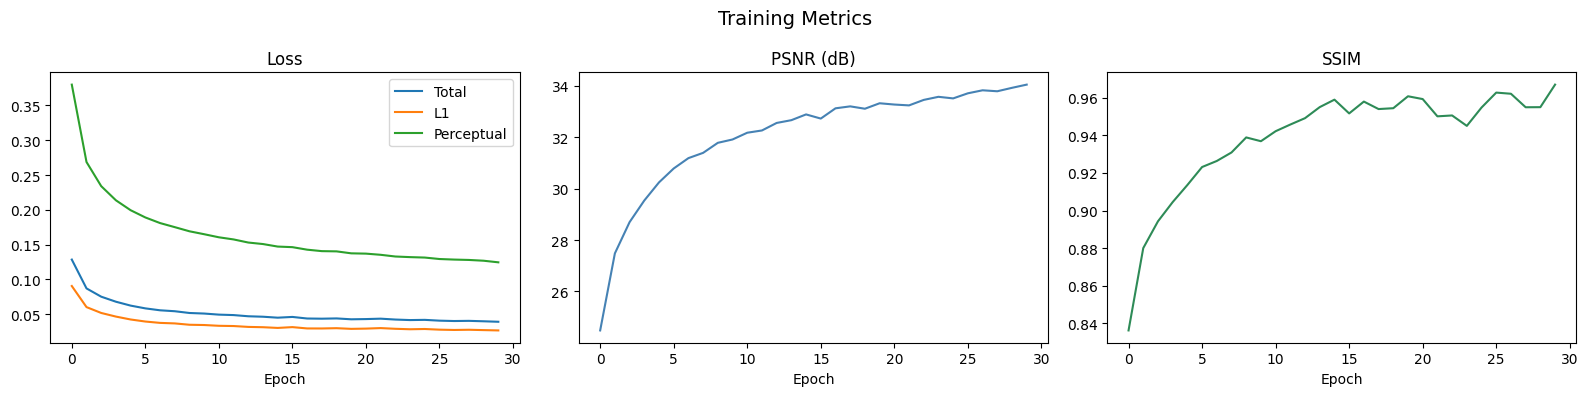

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["loss"],  label="Total");  axes[0].plot(history["l1"], label="L1")
axes[0].plot(history["perc"], label="Perceptual")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history["psnr"], color="steelblue")
axes[1].set_title("PSNR (dB)"); axes[1].set_xlabel("Epoch")

axes[2].plot(history["ssim"], color="seagreen")
axes[2].set_title("SSIM"); axes[2].set_xlabel("Epoch")

plt.suptitle("Training Metrics", fontsize=14)
plt.tight_layout()
plt.savefig("metrics.png")
plt.show()


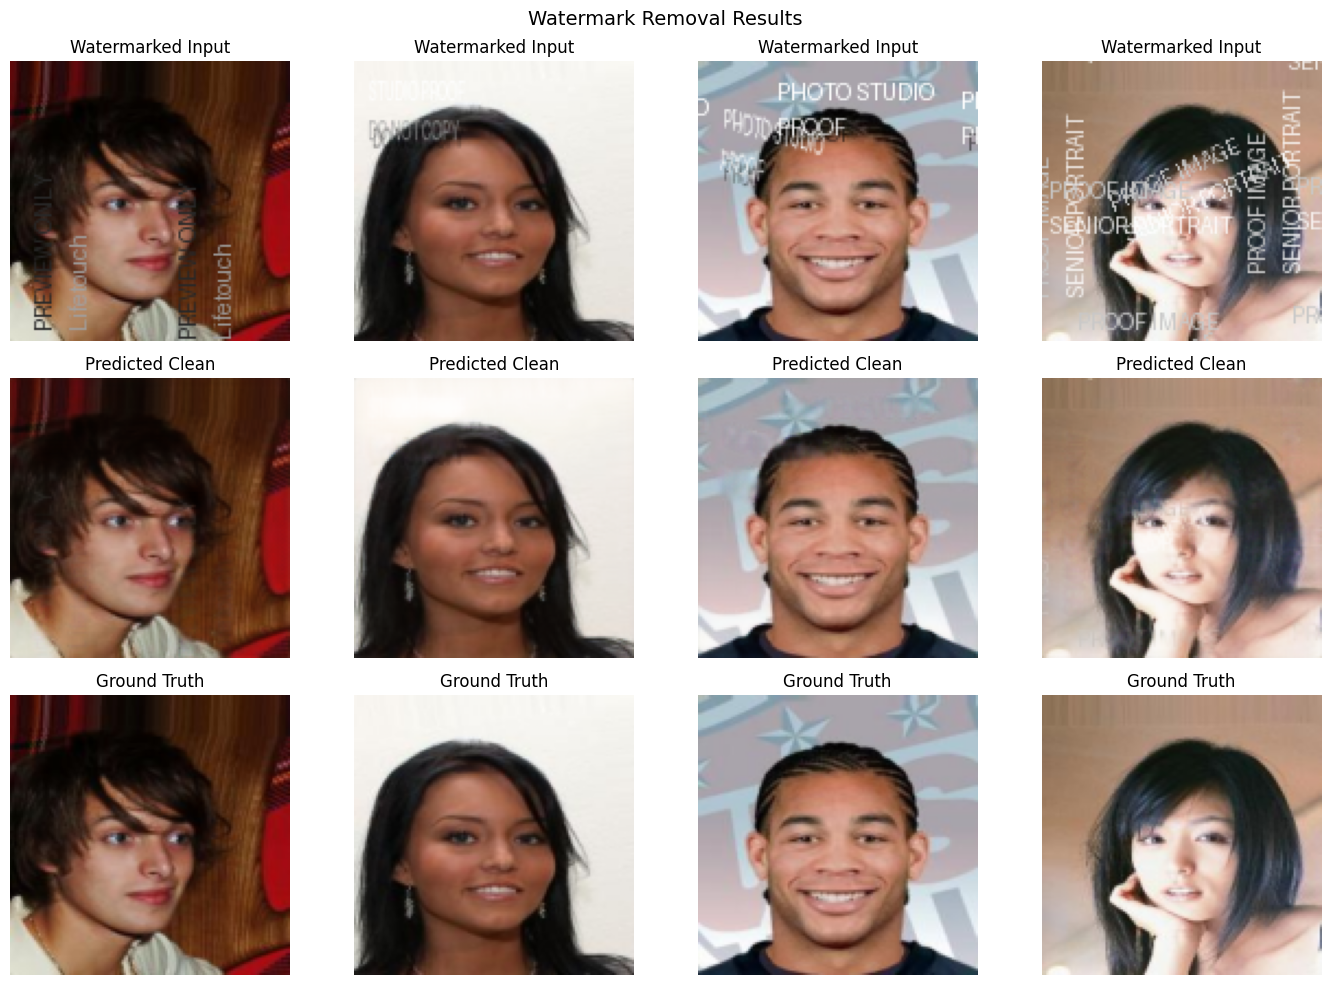

In [32]:
model.eval()

denorm = transforms.Normalize(
    mean=[-1, -1, -1],
    std =[2,   2,  2]   # undoes the [-1,1] normalization → [0,1]
)


sample_loader = DataLoader(
    StreamingWatermarkDataset(REPO_ID, split="train", max_samples=BATCH_SIZE),
    batch_size=BATCH_SIZE
)
watermarked, clean = next(iter(sample_loader))
watermarked, clean = watermarked.to(DEVICE), clean.to(DEVICE)

with torch.no_grad():
    pred = model(watermarked)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
titles = ["Watermarked Input", "Predicted Clean", "Ground Truth"]

for col in range(4):
    for row, tensor in enumerate([watermarked, pred, clean]):
        img = denorm(tensor[col].cpu()).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[row][col].imshow(img)
        axes[row][col].set_title(titles[row])
        axes[row][col].axis("off")

plt.suptitle("Watermark Removal Results", fontsize=14)
plt.tight_layout()
plt.savefig("WaterMark Removal Results")
plt.show()


In [27]:
from huggingface_hub import HfApi, login, ModelCard

MODEL_REPO_ID = "GeraldNdawula/Watermark_Removal_UNet"


final_path = os.path.join(CHECKPOINT_DIR, "unet_final.pth")
torch.save({
    "model":        model.state_dict(),
    "image_size":   IMAGE_SIZE,
    "architecture": "UNet",
    "epochs":       EPOCHS,
    "history":      history
}, final_path)
print(f"Model saved locally → {final_path}")


login()
api = HfApi()


api.create_repo(
    repo_id=MODEL_REPO_ID,
    repo_type="model",
    exist_ok=True,
    private=False
)


api.upload_file(
    path_or_fileobj=final_path,
    path_in_repo="unet_final.pth",
    repo_id=MODEL_REPO_ID,
    repo_type="model",
    commit_message="Upload final U-Net watermark removal model"
)


for ckpt in sorted(os.listdir(CHECKPOINT_DIR)):
    if ckpt.endswith(".pth") and "epoch" in ckpt:
        api.upload_file(
            path_or_fileobj=os.path.join(CHECKPOINT_DIR, ckpt),
            path_in_repo=f"checkpoints/{ckpt}",
            repo_id=MODEL_REPO_ID,
            repo_type="model",
            commit_message=f"Upload checkpoint {ckpt}"
        )
        print(f"Uploaded checkpoint → {ckpt}")


final_psnr = history["psnr"][-1]
final_ssim = history["ssim"][-1]

card_content = f"""---
language: en
license: mit
tags:
  - image-to-image
  - watermark-removal
  - unet
  - pytorch
datasets:
  - GeraldNdawula/Watermark_Dataset
metrics:
  - psnr
  - ssim
---

# Watermark Removal U-Net

A U-Net model trained to remove synthetic proof-style watermarks from portrait images.

## Training

| Setting        | Value                              |
|----------------|------------------------------------|
| Architecture   | U-Net (64→128→256→512 features)    |
| Dataset        | GeraldNdawula/Watermark_Dataset    |
| Image size     | {IMAGE_SIZE}×{IMAGE_SIZE}          |
| Epochs         | {EPOCHS}                           |
| Optimizer      | Adam (lr={LR})                     |
| Loss           | L1 + Perceptual (VGG16, λ={LAMBDA_PERC}) |

## Final Metrics

| Metric | Value        |
|--------|--------------|
| PSNR   | {final_psnr:.2f} dB |
| SSIM   | {final_ssim:.4f}    |

## Usage

```python
import torch
from huggingface_hub import hf_hub_download

# Load model
ckpt = torch.load(hf_hub_download("{MODEL_REPO_ID}", "unet_final.pth"))
model = UNet()
model.load_state_dict(ckpt["model"])
model.eval()

# Inference
import torchvision.transforms as transforms
transform = transforms.Compose([
    transforms.Resize(({IMAGE_SIZE}, {IMAGE_SIZE})),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

watermarked_tensor = transform(your_pil_image).unsqueeze(0)
with torch.no_grad():
    clean_tensor = model(watermarked_tensor)

# Back to PIL
denorm = transforms.Normalize([-1,-1,-1], [2,2,2])
clean_img = transforms.ToPILImage()(denorm(clean_tensor.squeeze()).clamp(0,1))
```
"""

with open("README.md", "w") as f:
    f.write(card_content)

api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id=MODEL_REPO_ID,
    repo_type="model",
    commit_message="Add model card"
)

os.remove("README.md")

print(f"\nModel fully pushed.")
print(f"https://huggingface.co/GeraldNdawula/Watermark_Removal_UNet")

Model saved locally → checkpoints/unet_final.pth


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  checkpoints/unet_final.pth  :   5%|5         | 6.71MB /  124MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Uploaded checkpoint → unet_epoch025.pth


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...kpoints/unet_epoch030.pth:  33%|###2      |  122MB /  373MB            

Uploaded checkpoint → unet_epoch030.pth

Model fully pushed.
https://huggingface.co/GeraldNdawula/Watermark_Removal_UNet
